In [2]:
import pandas as pd


df = pd.read_csv("olist_customer_base_dataset.csv")

In [3]:
df=df.drop(columns=['last_purchase_date'])

In [4]:
df.isnull().sum() #check for missing values

customer_unique_id             0
num_orders                     0
total_spent                    0
avg_order_value                0
avg_item_price_per_order       0
avg_items_per_order            0
avg_review                   603
avg_installments               1
city                           0
state                          0
latitude                     254
longitude                    254
recency_days                   8
num_product_categories         0
most_bought_category        1279
least_bought_category       1279
most_used_payment              1
least_used_payment             1
dtype: int64

In [5]:
#impute missing numerical values with the mean 
df['latitude']=df['latitude'].fillna(df['latitude'].mean())
df['longitude']=df['longitude'].fillna(df['longitude'].mean())
df['avg_review']=df['avg_review'].fillna(df['avg_review'].mean())
df['avg_installments']=df['avg_installments'].fillna(df['avg_installments'].mean())
df['recency_days']=df['recency_days'].fillna(df['recency_days'].mean())


In [6]:
#impute missing text values with mode
df['least_used_payment']=df['least_used_payment'].fillna(df['least_used_payment'].mode()[0])
df['most_used_payment']=df['most_used_payment'].fillna(df['most_used_payment'].mode()[0])

In [7]:

df['most_bought_category']=df['most_bought_category'].fillna(df['most_bought_category'].mode()[0])
df['least_bought_category']=df['least_bought_category'].fillna(df['least_bought_category'].mode()[0])

In [8]:
df.isnull().sum() #check for missing values

customer_unique_id          0
num_orders                  0
total_spent                 0
avg_order_value             0
avg_item_price_per_order    0
avg_items_per_order         0
avg_review                  0
avg_installments            0
city                        0
state                       0
latitude                    0
longitude                   0
recency_days                0
num_product_categories      0
most_bought_category        0
least_bought_category       0
most_used_payment           0
least_used_payment          0
dtype: int64

In [9]:
df.to_csv("olist_no_missing_dataset.csv", index=False)

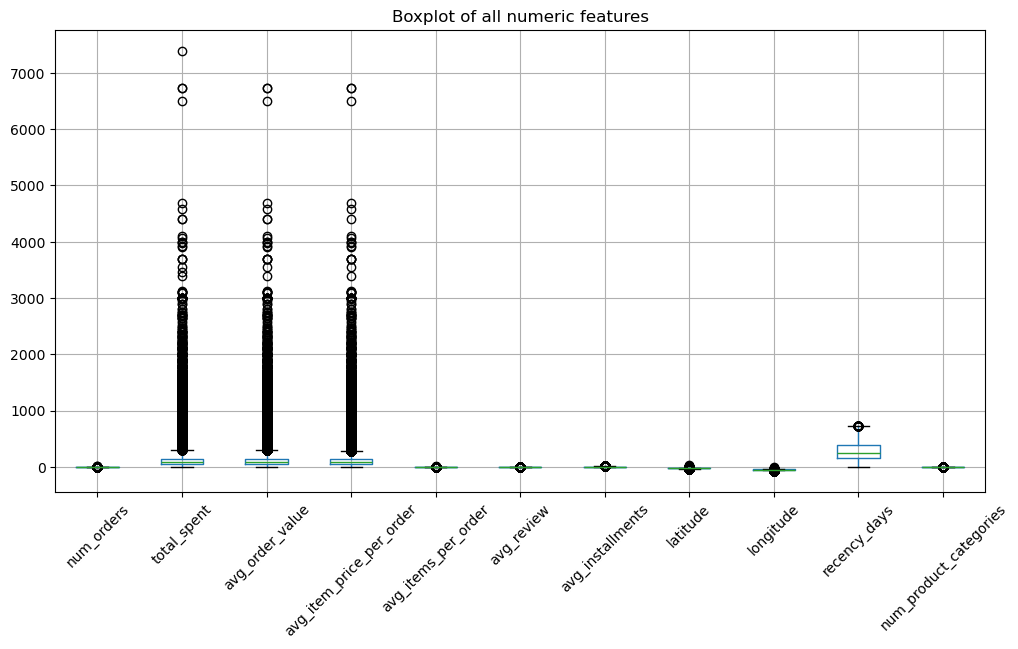

In [28]:
import matplotlib.pyplot as plt
# Create boxplot for all numeric columns in order to detect outliers
df.boxplot(figsize=(12, 6))
plt.title("Boxplot of all numeric features")
plt.xticks(rotation=45)
plt.show()

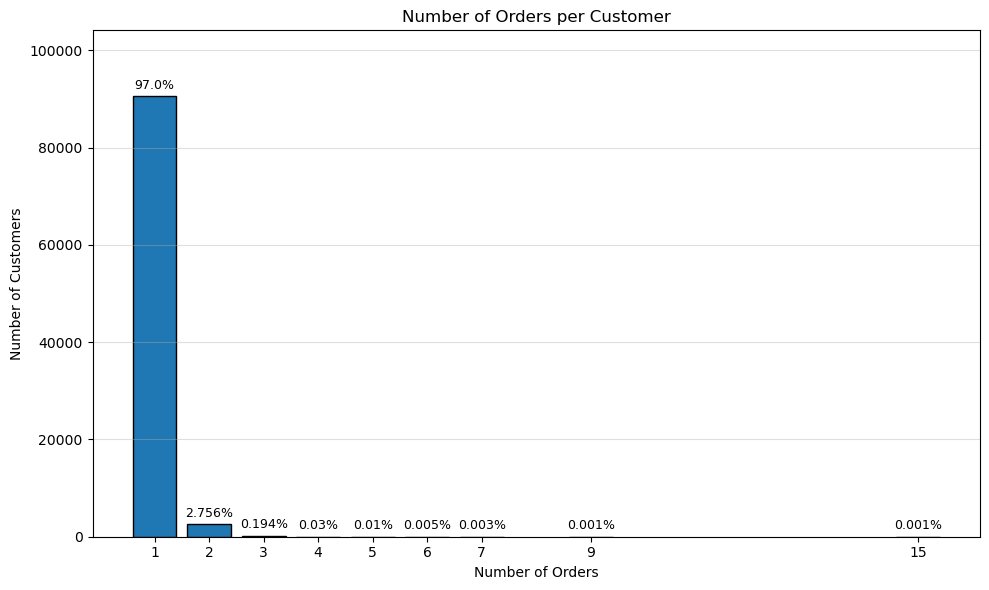

In [40]:
# Count and percentage
order_counts = df['num_orders'].value_counts().sort_index()
order_percentages = (order_counts / order_counts.sum() * 100).round(3)

plt.figure(figsize=(10,6))

# Add small spacing between bars using width < 1
bars = plt.bar(order_counts.index, order_counts.values, width=0.8, edgecolor='black')

plt.title('Number of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)

# Ensure every integer tick shows and is rotated slightly
plt.xticks(order_counts.index, rotation=0)

# Add percentage labels slightly higher to prevent overlap
for bar, pct in zip(bars, order_percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(order_counts.values)*0.01,  # lift text 1% above bar height
        f'{pct}%',
        ha='center', va='bottom', fontsize=9
    )

# Add extra space at top so labels don’t get cut off
plt.ylim(0, max(order_counts.values)*1.15)

plt.tight_layout()
plt.show()

count    93358.000000
mean       133.020307
std        198.530069
min          0.850000
25%         44.900000
50%         82.900000
75%        149.000000
90%        259.900000
95%        389.913500
99%        969.000000
max       7388.000000
Name: total_spent, dtype: float64


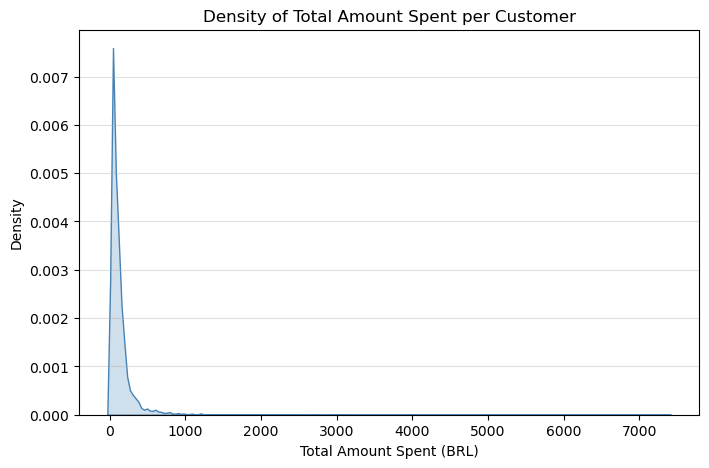

In [48]:
import seaborn as sns
stats = df['total_spent'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(stats)
plt.figure(figsize=(8,5))
sns.kdeplot(df['total_spent'], fill=True, bw_adjust=0.5, color='steelblue')
plt.title('Density of Total Amount Spent per Customer')
plt.xlabel('Total Amount Spent (BRL)')
plt.ylabel('Density')

plt.grid(axis='y', alpha=0.4)
plt.show()

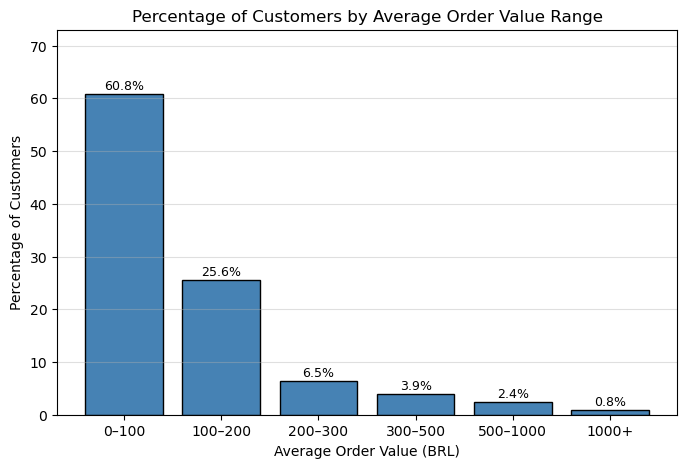

In [50]:
# Define bins and labels
bins = [0, 100, 200, 300, 500, 1000, float('inf')]
labels = ['0–100', '100–200', '200–300', '300–500', '500–1000', '1000+']

# Create a new categorical column
df['aov_range'] = pd.cut(df['avg_order_value'], bins=bins, labels=labels, right=False)

# Compute percentage of customers in each range
aov_dist = df['aov_range'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(8,5))
bars = plt.bar(aov_dist.index, aov_dist.values, color='steelblue', edgecolor='black')

plt.title('Percentage of Customers by Average Order Value Range')
plt.xlabel('Average Order Value (BRL)')
plt.ylabel('Percentage of Customers')
plt.grid(axis='y', alpha=0.4)

# Add percentage labels on top of bars
for bar, pct in zip(bars, aov_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.ylim(0, aov_dist.max() * 1.2)
plt.show()


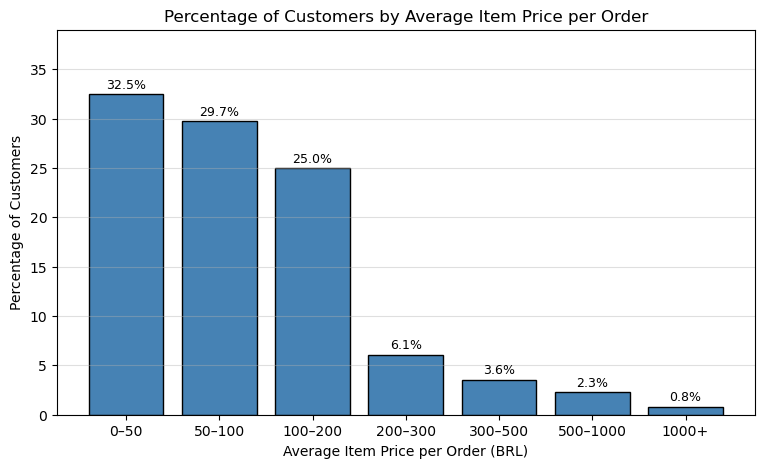

In [53]:
# Define bins and labels for item price ranges
bins = [0, 50, 100, 200, 300, 500, 1000, float('inf')]
labels = ['0–50', '50–100', '100–200', '200–300', '300–500', '500–1000', '1000+']

# Bin the variable
df['avg_item_price_range'] = pd.cut(df['avg_item_price_per_order'], bins=bins, labels=labels, right=False)

# Calculate percentage distribution
price_dist = df['avg_item_price_range'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(9,5))
bars = plt.bar(price_dist.index, price_dist.values, color='steelblue', edgecolor='black')

plt.title('Percentage of Customers by Average Item Price per Order')
plt.xlabel('Average Item Price per Order (BRL)')
plt.ylabel('Percentage of Customers')
plt.grid(axis='y', alpha=0.4)

# Add percentage labels on bars
for bar, pct in zip(bars, price_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.ylim(0, price_dist.max() * 1.2)
plt.show()

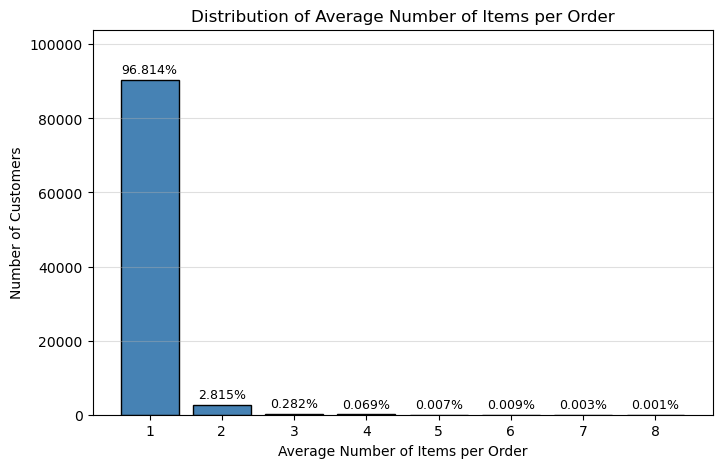

In [57]:
# Compute histogram values manually
counts, bins = np.histogram(df['avg_items_per_order'],
                            bins=range(1, int(df['avg_items_per_order'].max()) + 2))

# Calculate percentages
percentages = counts / counts.sum() * 100

plt.figure(figsize=(8,5))
bars = plt.bar(bins[:-1], counts, width=0.8, edgecolor='black', color='steelblue')

plt.title('Distribution of Average Number of Items per Order')
plt.xlabel('Average Number of Items per Order')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)
plt.xticks(bins[:-1])

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01,  # slight offset
             f'{pct:.3f}%', ha='center', va='bottom', fontsize=9)

plt.ylim(0, max(counts)*1.15)  # add space at top for labels
plt.show()

count    93358.000000
mean         4.153642
std          1.276017
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
90%          5.000000
95%          5.000000
99%          5.000000
max          5.000000
Name: avg_review, dtype: float64


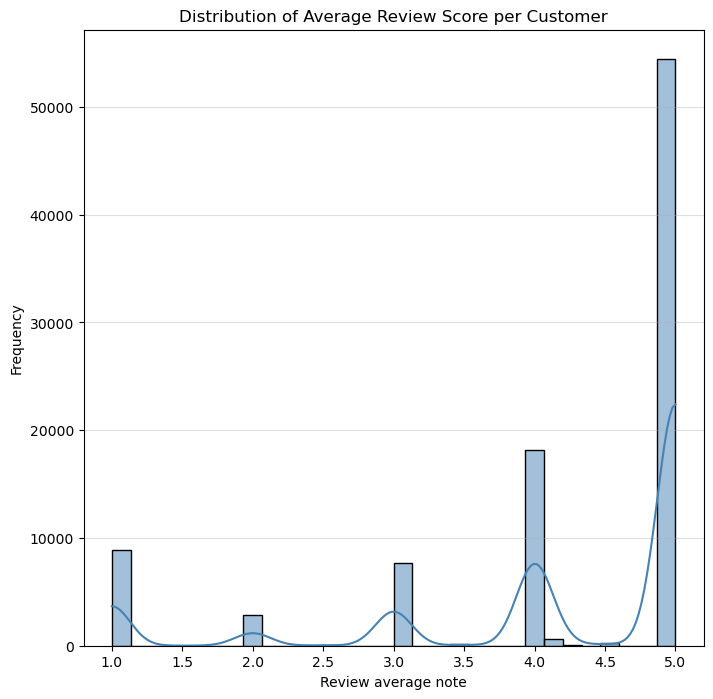

In [63]:
stats = df['avg_review'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(stats)
plt.figure(figsize=(8,8))
sns.histplot(df['avg_review'], bins=30, kde=True, color='steelblue', alpha=0.5)

plt.title('Distribution of Average Review Score per Customer')
plt.xlabel('Review average note')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.4)
plt.show()

count    93358.000000
mean         2.900838
std          2.685443
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
90%          8.000000
95%         10.000000
99%         10.000000
max         24.000000
Name: avg_installments, dtype: float64


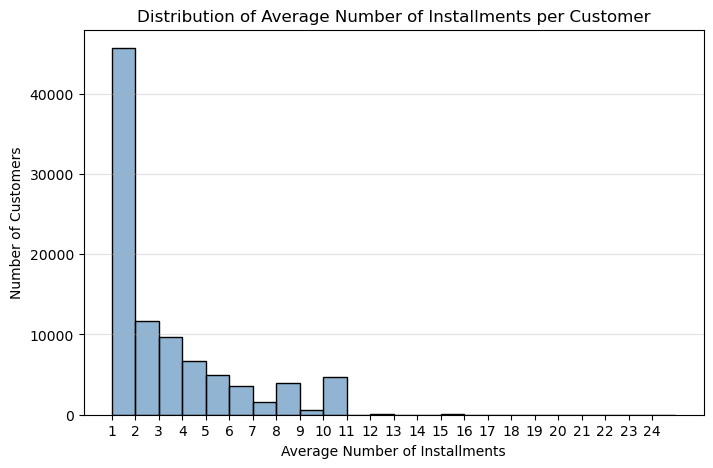

In [68]:
stats = df['avg_installments'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(stats)
plt.figure(figsize=(8,5))
sns.histplot(df['avg_installments'], bins=range(1, int(df['avg_installments'].max()) + 2),
            color='steelblue', edgecolor='black', alpha=0.6)

plt.title('Distribution of Average Number of Installments per Customer')
plt.xlabel('Average Number of Installments')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)
plt.xticks(range(1, int(df['avg_installments'].max()) + 1))
plt.show()

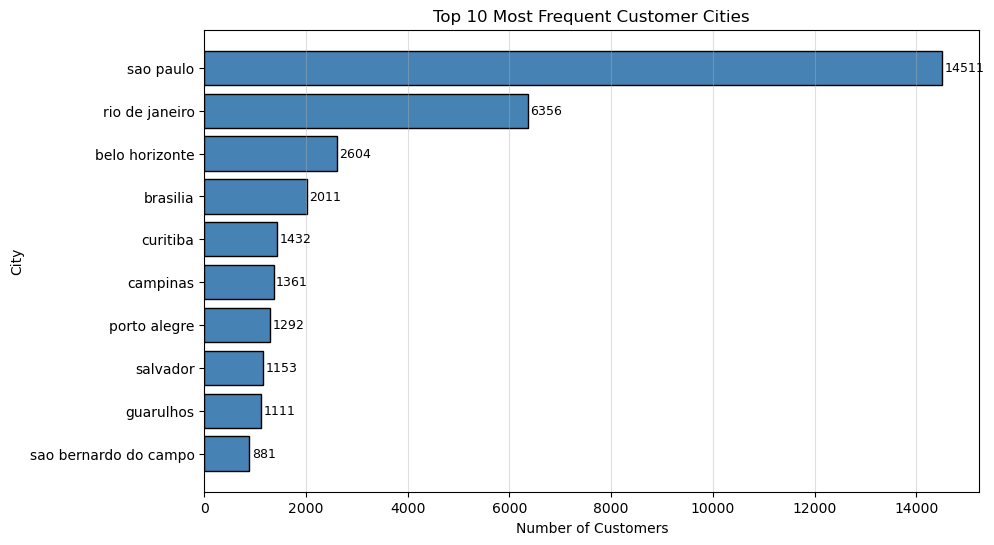

In [70]:
# Get top 10 cities
top_cities = df['city'].value_counts().nlargest(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_cities.index, top_cities.values, color='steelblue', edgecolor='black')

plt.title('Top 10 Most Frequent Customer Cities')
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.grid(axis='x', alpha=0.4)

# Add counts to bars
for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=9)

plt.gca().invert_yaxis()  # largest on top
plt.show()

C:\Users\konin\AppData\Local\Temp\ipykernel_4472\2950388440.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='Spectral')


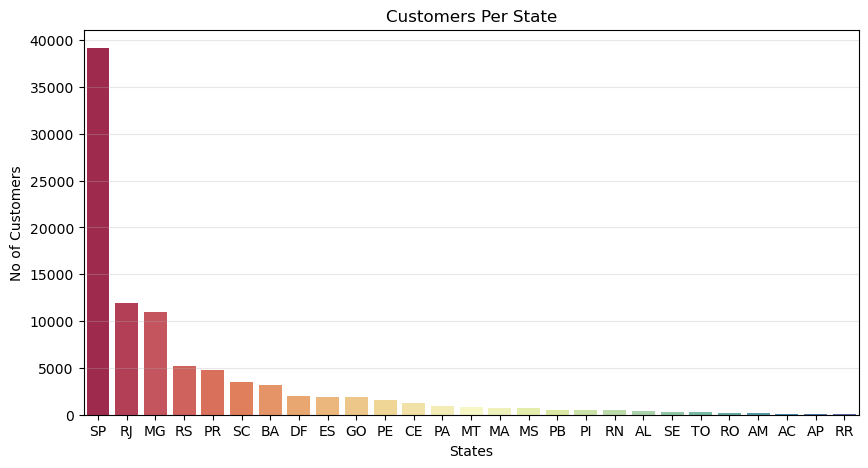

In [73]:
# Count customers per state
state_counts = df['state'].value_counts()

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='Spectral')

plt.title('Customers Per State')
plt.xlabel('States')
plt.ylabel('No of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [1]:
import plotly.express as px

fig = px.density_mapbox(
    df,
    lat='latitude',
    lon='longitude',
    radius=6,                     # adjust blur radius
    center=dict(lat=-15, lon=-55), # roughly center of Brazil
    zoom=3.5,
    mapbox_style='carto-positron', # clean background map
    title='Customer Density Heatmap Across Brazil'
)
fig.show()


NameError: name 'df' is not defined

count    93358.000000
mean       273.145817
std        151.956945
min          0.000000
25%        152.000000
50%        253.000000
75%        383.000000
90%        503.000000
95%        554.000000
99%        612.430000
max        735.000000
Name: recency_days, dtype: float64


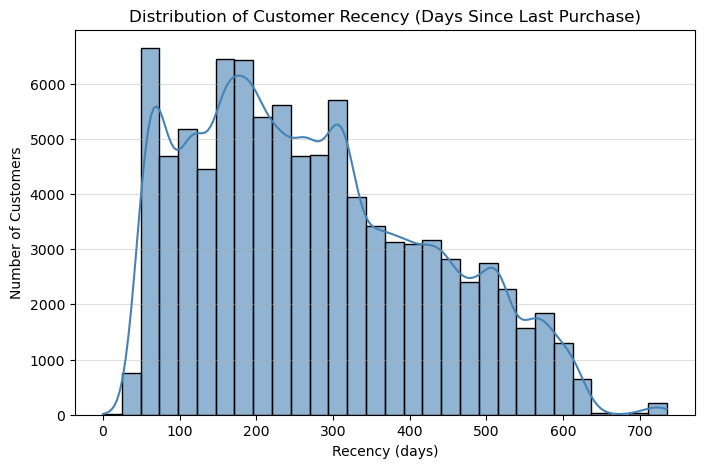

In [97]:
stats = df['recency_days'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(stats)
plt.figure(figsize=(8,5))
sns.histplot(
    df['recency_days'],
    bins=30,
    kde=True,
    color='steelblue',
    edgecolor='black',
    alpha=0.6
)

plt.title('Distribution of Customer Recency (Days Since Last Purchase)')
plt.xlabel('Recency (days)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)
plt.show()

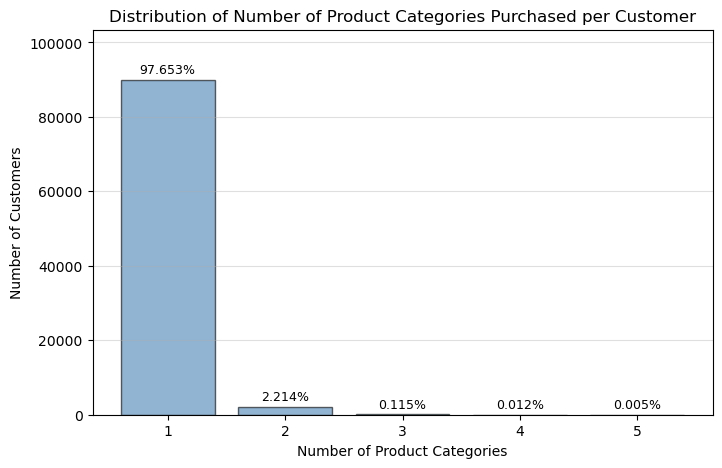

In [101]:
# Compute histogram values manually
counts, bins = np.histogram(
    df['num_product_categories'],
    bins=range(1, int(df['num_product_categories'].max()) + 2)
)

# Calculate percentages
percentages = counts / counts.sum() * 100

# Plot histogram
plt.figure(figsize=(8,5))
bars = plt.bar(bins[:-1], counts, width=0.8, edgecolor='black', color='steelblue', alpha=0.6)

plt.title('Distribution of Number of Product Categories Purchased per Customer')
plt.xlabel('Number of Product Categories')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)
plt.xticks(bins[:-1])

# Add percentage labels (3 decimal places)
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01,
             f'{pct:.3f}%', ha='center', va='bottom', fontsize=9)

plt.ylim(0, max(counts)*1.15)
plt.show()

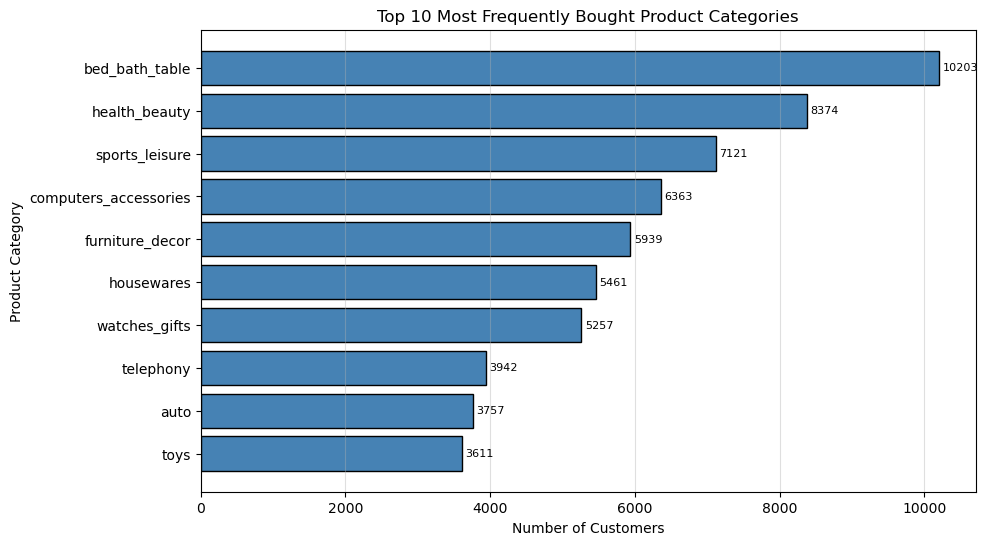

In [104]:
# Get top 10 most common categories
top_cats = df['most_bought_category'].value_counts().nlargest(10)

plt.figure(figsize=(10,6))
bars = plt.barh(top_cats.index, top_cats.values, color='steelblue', edgecolor='black')

plt.title('Top 10 Most Frequently Bought Product Categories')
plt.xlabel('Number of Customers')
plt.ylabel('Product Category')
plt.grid(axis='x', alpha=0.4)

# Add count labels
for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=8)

plt.gca().invert_yaxis()  # largest on top
plt.show()

C:\Users\konin\AppData\Local\Temp\ipykernel_4472\3049829526.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




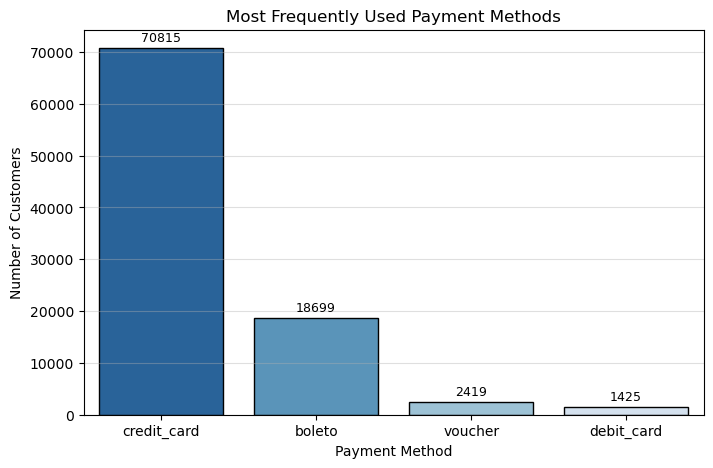

In [106]:
# Count most used payment types
payment_counts = df['most_used_payment'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values,
    palette='Blues_r',
    edgecolor='black'
)

plt.title('Most Frequently Used Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.4)

# Add count labels on top
for i, value in enumerate(payment_counts.values):
    plt.text(i, value + max(payment_counts.values)*0.01, str(value),
             ha='center', va='bottom', fontsize=9)

plt.show()

In [108]:
from sklearn.preprocessing import StandardScaler

# List of numerical columns
num_cols = [
    'num_orders',
    'total_spent',
    'avg_order_value',
    'avg_item_price_per_order',
    'avg_items_per_order',
    'avg_review',
    'avg_installments',
    'latitude',
    'longitude',
    'recency_days',
    'num_product_categories'
]

# Initialize and apply StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


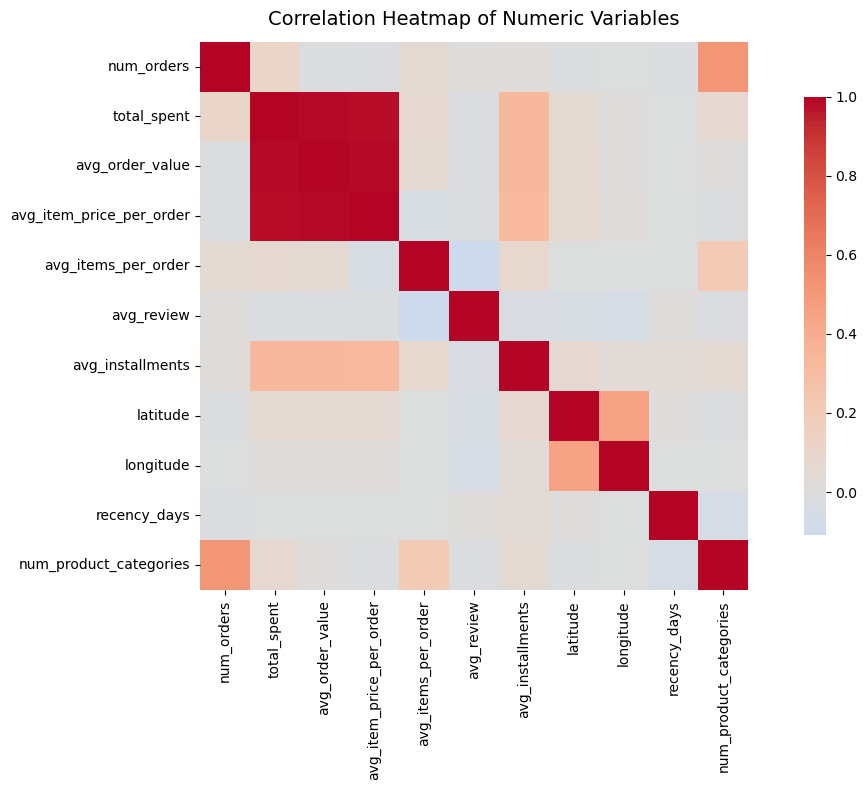

In [130]:
# --- Select only numeric columns ---
num_df = df.select_dtypes(include=['number'])

# --- Compute correlation matrix ---
corr = num_df.corr()

# --- Plot the heatmap ---
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False,          # set to True to show values
    fmt=".2f",
    square=True,
    linewidths=0,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [110]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[['most_used_payment']])

# Get new column names
encoded_cols = encoder.get_feature_names_out(['most_used_payment'])

# Create a DataFrame with encoded columns
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

# Combine with original DataFrame (drop old column)
df_final = pd.concat([df.drop(columns=['most_used_payment']), df_encoded], axis=1)

In [125]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Load pretrained model (compact, fast, 384-d embeddings)
model = SentenceTransformer("all-MiniLM-L6-v2")

# Ensure column exists and convert to strings
texts = df_final["most_bought_category"].fillna("unknown").astype(str).tolist()

# Generate embeddings (each is a 384-dimensional vector)
embeddings = model.encode(texts, show_progress_bar=True)
pca = PCA(n_components=10, random_state=42)
emb_pca = pca.fit_transform(embeddings)

emb_pca_df = pd.DataFrame(emb_pca, columns=[f"cat_pca_{i}" for i in range(1, 11)])
final_df_embedded = pd.concat([df_final.reset_index(drop=True), emb_pca_df], axis=1)

Batches:   0%|          | 0/2918 [00:00<?, ?it/s]

In [126]:
final_df_embedded

,customer_unique_id,num_orders,total_spent,avg_order_value,avg_item_price_per_order,avg_items_per_order,avg_review,avg_installments,city,state,latitude,longitude,recency_days,num_product_categories,most_bought_category,least_bought_category,least_used_payment,aov_range,avg_item_price_range,most_used_payment_boleto,most_used_payment_credit_card,most_used_payment_debit_card,most_used_payment_voucher,cat_pca_1,cat_pca_2,cat_pca_3,cat_pca_4,cat_pca_5,cat_pca_6,cat_pca_7,cat_pca_8,cat_pca_9,cat_pca_10
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.159829,-0.015717,0.003713,0.021035,-0.172165,0.663285,1.898826,cajamar,SP,-0.383518,-0.158997,-0.790661,-0.053651,bed_bath_table,bed_bath_table,credit_card,100–200,100–200,0.0,1.0,0.0,0.0,-0.637624,-0.327896,-0.102259,0.059743,-0.020116,0.189493,-0.198020,0.051733,0.008437,0.073418
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.159829,-0.574829,-0.570550,-0.561497,-0.172165,-0.120408,-0.707834,osasco,SP,-0.422565,-0.148502,-0.751176,-0.053651,health_beauty,health_beauty,credit_card,0–100,0–50,0.0,1.0,0.0,0.0,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
2,0000f46a3911fa3c0805444483337064,-0.159829,-0.322473,-0.311356,-0.298570,-0.172165,-0.904101,1.898826,sao jose,SC,-1.133248,-0.604148,1.881163,-0.053651,stationery,stationery,credit_card,0–100,50–100,0.0,1.0,0.0,0.0,-0.018761,-0.047356,-0.095521,0.369686,0.141457,-0.068647,0.166585,0.079676,0.160974,-0.034467
3,0000f6ccb0745a6a4b88665a16c9f078,-0.159829,-0.539117,-0.533870,-0.524289,-0.172165,-0.120408,0.409306,belem,PA,3.546167,-0.567054,0.499185,-0.053651,telephony,telephony,credit_card,0–100,0–50,0.0,1.0,0.0,0.0,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
4,0004aac84e0df4da2b147fca70cf8255,-0.159829,0.236639,0.262908,0.283963,-0.172165,0.663285,1.154066,sorocaba,SP,-0.413009,-0.316877,0.328083,-0.053651,telephony,telephony,credit_card,100–200,100–200,0.0,1.0,0.0,0.0,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,-0.159829,7.238135,7.454133,3.459029,4.284975,0.663285,2.643586,sanharo,PE,2.288431,2.375666,1.282306,-0.053651,health_beauty,health_beauty,credit_card,1000+,500–1000,0.0,1.0,0.0,0.0,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
93354,fffea47cd6d3cc0a88bd621562a9d061,-0.159829,-0.343176,-0.332619,-0.320140,-0.172165,-0.120408,-0.707834,feira de santana,BA,1.600739,1.783962,0.045106,-0.053651,baby,baby,credit_card,0–100,50–100,0.0,1.0,0.0,0.0,0.135171,0.216795,0.033849,0.272789,0.337885,-0.103309,-0.304037,-0.196557,0.221637,0.099556
93355,ffff371b4d645b6ecea244b27531430a,-0.159829,-0.217199,-0.203229,-0.188886,-0.172165,0.663285,-0.707834,sinop,MT,1.669036,-2.301202,2.164139,-0.053651,auto,auto,credit_card,0–100,50–100,0.0,1.0,0.0,0.0,0.294390,0.044495,-0.061878,0.295636,-0.110412,0.192365,-0.224561,-0.345526,0.011077,-0.522030
93356,ffff5962728ec6157033ef9805bacc48,-0.159829,-0.090769,-0.073373,-0.057160,-0.172165,0.663285,0.781686,bom jesus do norte,ES,0.011389,1.114120,-0.770919,-0.053651,watches_gifts,watches_gifts,credit_card,100–200,100–200,0.0,1.0,0.0,0.0,0.158176,0.013189,-0.062204,-0.312452,0.603046,0.140091,-0.017123,0.195443,-0.321531,-0.130718


In [127]:
final_df_embedded.drop(columns=['city','state','aov_range','avg_item_price_range','least_bought_category','least_used_payment'])

,customer_unique_id,num_orders,total_spent,avg_order_value,avg_item_price_per_order,avg_items_per_order,avg_review,avg_installments,latitude,longitude,recency_days,num_product_categories,most_bought_category,most_used_payment_boleto,most_used_payment_credit_card,most_used_payment_debit_card,most_used_payment_voucher,cat_pca_1,cat_pca_2,cat_pca_3,cat_pca_4,cat_pca_5,cat_pca_6,cat_pca_7,cat_pca_8,cat_pca_9,cat_pca_10
0,0000366f3b9a7992bf8c76cfdf3221e2,-0.159829,-0.015717,0.003713,0.021035,-0.172165,0.663285,1.898826,-0.383518,-0.158997,-0.790661,-0.053651,bed_bath_table,0.0,1.0,0.0,0.0,-0.637624,-0.327896,-0.102259,0.059743,-0.020116,0.189493,-0.198020,0.051733,0.008437,0.073418
1,0000b849f77a49e4a4ce2b2a4ca5be3f,-0.159829,-0.574829,-0.570550,-0.561497,-0.172165,-0.120408,-0.707834,-0.422565,-0.148502,-0.751176,-0.053651,health_beauty,0.0,1.0,0.0,0.0,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
2,0000f46a3911fa3c0805444483337064,-0.159829,-0.322473,-0.311356,-0.298570,-0.172165,-0.904101,1.898826,-1.133248,-0.604148,1.881163,-0.053651,stationery,0.0,1.0,0.0,0.0,-0.018761,-0.047356,-0.095521,0.369686,0.141457,-0.068647,0.166585,0.079676,0.160974,-0.034467
3,0000f6ccb0745a6a4b88665a16c9f078,-0.159829,-0.539117,-0.533870,-0.524289,-0.172165,-0.120408,0.409306,3.546167,-0.567054,0.499185,-0.053651,telephony,0.0,1.0,0.0,0.0,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
4,0004aac84e0df4da2b147fca70cf8255,-0.159829,0.236639,0.262908,0.283963,-0.172165,0.663285,1.154066,-0.413009,-0.316877,0.328083,-0.053651,telephony,0.0,1.0,0.0,0.0,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,-0.159829,7.238135,7.454133,3.459029,4.284975,0.663285,2.643586,2.288431,2.375666,1.282306,-0.053651,health_beauty,0.0,1.0,0.0,0.0,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
93354,fffea47cd6d3cc0a88bd621562a9d061,-0.159829,-0.343176,-0.332619,-0.320140,-0.172165,-0.120408,-0.707834,1.600739,1.783962,0.045106,-0.053651,baby,0.0,1.0,0.0,0.0,0.135171,0.216795,0.033849,0.272789,0.337885,-0.103309,-0.304037,-0.196557,0.221637,0.099556
93355,ffff371b4d645b6ecea244b27531430a,-0.159829,-0.217199,-0.203229,-0.188886,-0.172165,0.663285,-0.707834,1.669036,-2.301202,2.164139,-0.053651,auto,0.0,1.0,0.0,0.0,0.294390,0.044495,-0.061878,0.295636,-0.110412,0.192365,-0.224561,-0.345526,0.011077,-0.522030
93356,ffff5962728ec6157033ef9805bacc48,-0.159829,-0.090769,-0.073373,-0.057160,-0.172165,0.663285,0.781686,0.011389,1.114120,-0.770919,-0.053651,watches_gifts,0.0,1.0,0.0,0.0,0.158176,0.013189,-0.062204,-0.312452,0.603046,0.140091,-0.017123,0.195443,-0.321531,-0.130718


In [131]:
# Save processed dataset
final_df_embedded.to_csv("olist_cleaned_dataset.csv", index=False)